# Step 1: Test YOLO — Can It Detect a Phone?

We're testing the **pre-trained** YOLO model. It already knows 80 objects including phones.

Run each cell with **Shift+Enter**. Read the comments to understand what's happening.

## Cell 1: Import YOLO
This loads the YOLO library. Like opening your toolbox before starting work.

In [1]:
# Import YOLO from the ultralytics package
from ultralytics import YOLO

# Import OpenCV for camera and image handling
import cv2

# Import matplotlib to display images inside the notebook
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Cell 2: Load the pre-trained YOLO model

This downloads the YOLOv8 nano model (smallest, fastest).
- First run: downloads ~6MB model file
- Next runs: loads from disk instantly

This model was trained by Ultralytics on **millions** of images. It already knows what phones, people, laptops, chairs look like.

In [2]:
# Load YOLOv8 nano model (pre-trained on COCO dataset - 80 object types)
model = YOLO('yolov8n.pt')

print("Model loaded!")
print(f"This model can detect {len(model.names)} types of objects:")
print(list(model.names.values()))

Model loaded!
This model can detect 80 types of objects:
['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']


## Cell 3: Capture one photo from your webcam

**Before running this cell:**
1. Place your **phone on the desk** in front of your webcam
2. Make sure the phone is visible to the camera
3. Then run this cell

This will:
1. Open your webcam
2. Take ONE photo
3. Close the webcam
4. Show you the photo

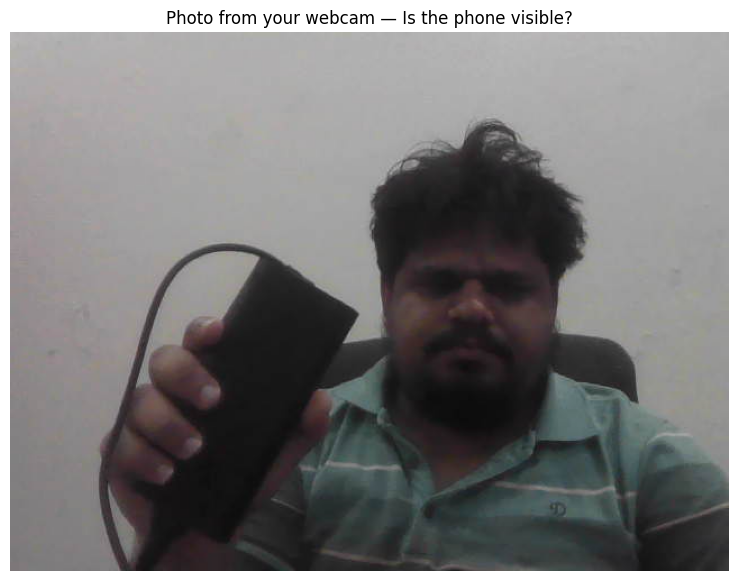

Photo captured and saved as 'test_photo.jpg'
Can you see your phone in the image above?


In [11]:
# Open webcam (0 = default camera)
camera = cv2.VideoCapture(0)

# Wait a moment for camera to warm up
import time
time.sleep(2)

# Capture one frame
success, photo = camera.read()

# Release the camera
camera.release()

if success:
    # Save the photo
    cv2.imwrite('test_photo.jpg', photo)
    
    # Display it in the notebook
    # OpenCV uses BGR color, matplotlib uses RGB, so we convert
    photo_rgb = cv2.cvtColor(photo, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 7))
    plt.imshow(photo_rgb)
    plt.title('Photo from your webcam — Is the phone visible?')
    plt.axis('off')
    plt.show()
    
    print("Photo captured and saved as 'test_photo.jpg'")
    print("Can you see your phone in the image above?")
else:
    print("ERROR: Could not capture from webcam.")
    print("Try: Is another app using the camera? Close it and retry.")

## Cell 4: Run YOLO on your photo

Now the magic happens! We give YOLO the photo and ask: **"What do you see?"**

YOLO will:
1. Scan the entire image
2. Find all objects it recognizes
3. Draw boxes around them
4. Label each box (e.g., "cell phone 87%")

In [12]:
# Run YOLO on the captured photo
results = model('test_photo.jpg')

# Get the first result (we only have one image)
result = results[0]

# Print what YOLO found
print("=" * 50)
print("YOLO DETECTION RESULTS")
print("=" * 50)

if len(result.boxes) == 0:
    print("No objects detected! Try:")
    print("  - Moving the phone closer to the camera")
    print("  - Better lighting")
    print("  - Different angle")
else:
    for box in result.boxes:
        # Get the class name (what object it is)
        class_id = int(box.cls[0])
        class_name = model.names[class_id]
        
        # Get the confidence (how sure YOLO is)
        confidence = float(box.conf[0]) * 100
        
        # Print the result
        emoji = "📱" if "phone" in class_name.lower() else "📦"
        print(f"  {emoji} {class_name}: {confidence:.1f}% confident")
    
    print(f"\nTotal objects found: {len(result.boxes)}")


image 1/1 D:\AI Learning\usman\implementation\01_phone_detection\test_photo.jpg: 480x640 1 person, 72.1ms
Speed: 1.6ms preprocess, 72.1ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)
YOLO DETECTION RESULTS
  📦 person: 85.4% confident

Total objects found: 1


## Cell 5: Show the image WITH detection boxes

This shows your photo with boxes drawn around every detected object.
- Green/colored box = detected object
- Label shows: object name + confidence %

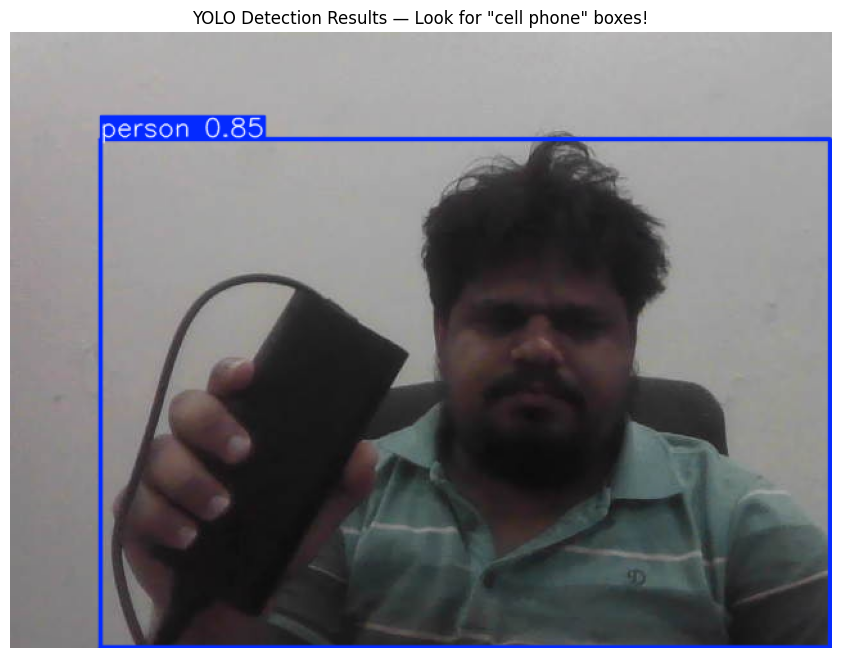

Annotated image saved as 'test_photo_detected.jpg'


In [13]:
# Get the image with boxes drawn on it
annotated_image = result.plot()

# Convert BGR to RGB for display
annotated_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(12, 8))
plt.imshow(annotated_rgb)
plt.title('YOLO Detection Results — Look for "cell phone" boxes!')
plt.axis('off')
plt.show()

# Save the annotated image
cv2.imwrite('test_photo_detected.jpg', annotated_image)
print("Annotated image saved as 'test_photo_detected.jpg'")

## Cell 6: Check — Did it work?

Run this cell to get a summary of how well YOLO performed on your setup.

In [10]:
# Count phone detections
phone_found = False
phone_confidence = 0

for box in result.boxes:
    class_name = model.names[int(box.cls[0])]
    if 'phone' in class_name.lower() or 'cell' in class_name.lower():
        phone_found = True
        phone_confidence = float(box.conf[0]) * 100

print("=" * 50)
print("EXAMGUARD PHONE DETECTION TEST")
print("=" * 50)

if phone_found:
    print(f"\n  PHONE DETECTED! Confidence: {phone_confidence:.1f}%")
    if phone_confidence > 85:
        print("  Verdict: EXCELLENT — Use YOLO as-is!")
    elif phone_confidence > 60:
        print("  Verdict: GOOD — Works, but fine-tuning would improve it.")
    else:
        print("  Verdict: WEAK — Needs fine-tuning with your own photos.")
else:
    print("\n  Phone NOT detected.")
    print("  Try these fixes:")
    print("    1. Move phone closer to camera")
    print("    2. Make sure phone screen is visible (not hidden)")
    print("    3. Better lighting (avoid dark room)")
    print("    4. Go back to Cell 3 and retake the photo")

print("\n" + "=" * 50)
print("Next step: Run 02_webcam_live.ipynb for LIVE detection!")

EXAMGUARD PHONE DETECTION TEST

  PHONE DETECTED! Confidence: 25.8%
  Verdict: WEAK — Needs fine-tuning with your own photos.

Next step: Run 02_webcam_live.ipynb for LIVE detection!
